In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = "../data/raw/"

orders   = pd.read_csv(path + "olist_orders_dataset.csv")
items    = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
mql      = pd.read_csv(path + "olist_marketing_qualified_leads_dataset.csv")
deals    = pd.read_csv(path + "olist_closed_deals_dataset.csv")

os.makedirs('../reports', exist_ok=True)
print("Loaded ✓")

Loaded ✓


In [2]:
channel_seller = mql.merge(deals[['mql_id','seller_id']], on='mql_id', how='inner')
channel_seller = channel_seller[['seller_id','origin']].dropna()

seller_orders = items[['order_id','seller_id','price']].merge(
    channel_seller, on='seller_id', how='inner')

seller_revenue = seller_orders.merge(
    payments[['order_id','payment_value']], on='order_id', how='left')

print(f"Pipeline rows : {seller_revenue.shape[0]}")
print(seller_revenue.head(3))

Pipeline rows : 5256
                           order_id                         seller_id  price  \
0  0005f50442cb953dcd1d21e1fb923495  ba143b05f0110f0dc71ad71b4466ce92  53.99   
1  001ac194d4a326a6fa99b581e9a3d963  ffc470761de7d0232558ba5e786e57b7  54.00   
2  0029f17cf0e7640c5cb6825af681303f  d3dcf0604eabf0224fbd5948b5e02f69  94.90   

        origin  payment_value  
0  paid_search          65.39  
1      unknown          62.54  
2      unknown         113.44  


In [3]:
channel_revenue = seller_revenue.groupby('origin').agg(
    total_revenue  = ('payment_value', 'sum'),
    total_orders   = ('order_id',      'nunique'),
    unique_sellers = ('seller_id',     'nunique')
).reset_index().round(2)

channel_revenue = channel_revenue.sort_values('total_revenue', ascending=False)
print(channel_revenue)

           origin  total_revenue  total_orders  unique_sellers
3  organic_search      293711.19          1208             113
8         unknown      282979.56          1280              81
5     paid_search      251088.18          1247             101
7          social       67671.60           392              31
0  direct_traffic       33242.73           193              31
6        referral       22026.48            69               9
4           other       10405.39            89               2
2           email        9229.57            22               6
1         display        1207.95             7               2


In [4]:
spend_map = {
    'paid_search'       : 50000,
    'social'            : 40000,
    'display'           : 20000,
    'email'             : 10000,
    'organic_search'    : 5000,
    'referral'          : 3000,
    'direct_traffic'    : 2000,
    'other_publicities' : 1000,
    'other'             : 500,
    'unknown'           : 0
}

conv = mql.merge(deals[['mql_id','seller_id']], on='mql_id', how='left')
conv['converted'] = conv['seller_id'].notna().astype(int)
conv_summary = conv.groupby('origin')['converted'].sum().reset_index()
conv_summary.columns = ['origin', 'converted_leads']

channel_revenue['assumed_spend'] = channel_revenue['origin'].map(spend_map)
channel_metrics = channel_revenue.merge(conv_summary, on='origin', how='left')

channel_metrics['CAC']  = (channel_metrics['assumed_spend'] / 
                            channel_metrics['converted_leads']).round(2)
channel_metrics['ROAS'] = (channel_metrics['total_revenue'] / 
                            channel_metrics['assumed_spend']).round(2)

print(channel_metrics[['origin','assumed_spend','converted_leads',
                         'total_revenue','CAC','ROAS']])

           origin  assumed_spend  converted_leads  total_revenue      CAC  \
0  organic_search           5000              271      293711.19    18.45   
1         unknown              0              179      282979.56     0.00   
2     paid_search          50000              195      251088.18   256.41   
3          social          40000               75       67671.60   533.33   
4  direct_traffic           2000               56       33242.73    35.71   
5        referral           3000               24       22026.48   125.00   
6           other            500                4       10405.39   125.00   
7           email          10000               15        9229.57   666.67   
8         display          20000                6        1207.95  3333.33   

    ROAS  
0  58.74  
1    inf  
2   5.02  
3   1.69  
4  16.62  
5   7.34  
6  20.81  
7   0.92  
8   0.06  


C:\Users\hp\AppData\Local\Temp\ipykernel_19316\2141357718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean.sort_values('CAC'), x='origin', y='CAC',
C:\Users\hp\AppData\Local\Temp\ipykernel_19316\2141357718.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
C:\Users\hp\AppData\Local\Temp\ipykernel_19316\2141357718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean.sort_values('ROAS', ascending=False), x='origin', y='ROAS',
C:\Users\hp\AppData\Local\Temp\ipykernel_19316\2141357718.py

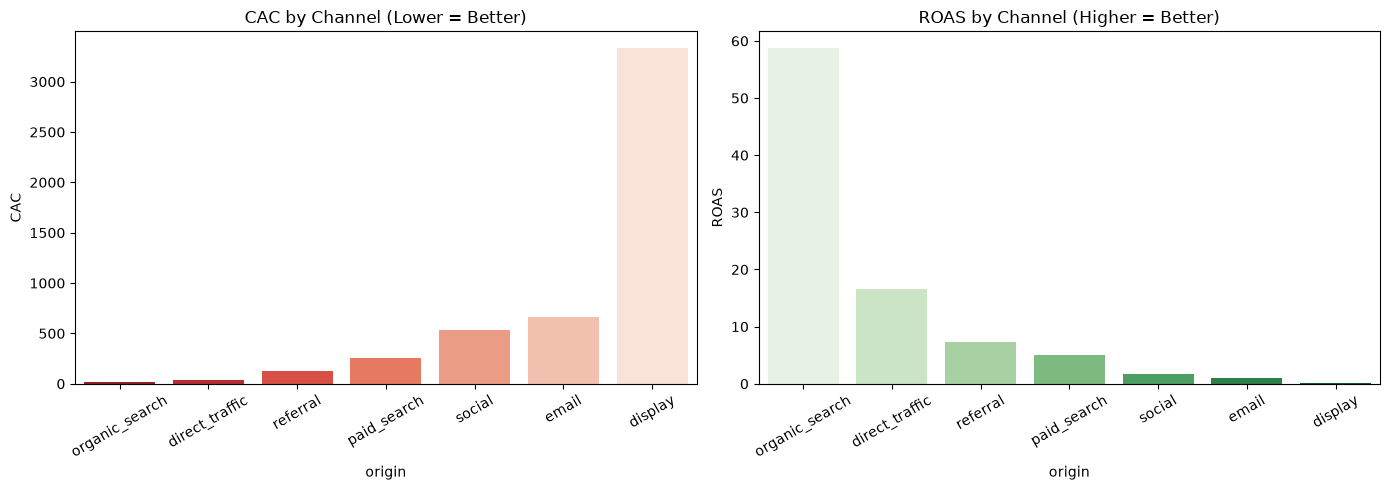

In [5]:
clean = channel_metrics[~channel_metrics['origin'].isin(['unknown','other'])].copy()
clean = clean[clean['assumed_spend'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=clean.sort_values('CAC'), x='origin', y='CAC',
            palette='Reds_r', ax=axes[0])
axes[0].set_title('CAC by Channel (Lower = Better)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

sns.barplot(data=clean.sort_values('ROAS', ascending=False), x='origin', y='ROAS',
            palette='Greens', ax=axes[1])
axes[1].set_title('ROAS by Channel (Higher = Better)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('../reports/02_cac_roas_by_channel.png', dpi=150)
plt.show()